# Experimento Simples

- 10 episódios 
- 20 agentes

* Cada agente é treinado com todos os passos do episódio exceto o último e testado no último passo
* Resultado é a médias do RMSE dos agentes em cada episódio

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmbrl.model import *
from pmbrl.data import *
from pmbrl.experiment import *


In [63]:
n_episodes = 10

data = [generate_episode() for _ in range(n_episodes)]
for i in data:
    print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


(79, 8)
(55, 8)
(24, 8)
(29, 8)
(34, 8)
(65, 8)
(40, 8)
(22, 8)
(11, 8)
(93, 8)


In [64]:
n_agents = 20

pmbrl = [Model(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]
mbrl = [ModelBase(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]

In [65]:
training = { # Traning:
    "mode": "all", # Mode of the PMBRL (All: learn parameters and Transitions)
    "debug": False, # Number of epochs on training
    "num_epochs": 1000, # Number of epochs on training
}

def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        X, y = build_train_data(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            agent.train(X[:-1], y[:-1], **training)
            s,r = agent.sample(X[-1:], mode=training['mode'])
            results.append(
                torch.concat([
                    torch.tensor([i, j]),
                    torch.mean((s - y[-1:,:-1])**2, axis=0)**.5,
                    torch.mean((r - y[-1:,-1])**2, axis=0)**.5
                ], axis=0)
            )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 's_0', 's_1', 'r']) 

# pmbrl_results = run(data, pmbrl)
# mbrl_results = run(data, mbrl)

In [66]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

pmbrl_plot = pmbrl_results.groupby(by='epi').mean()[['s_0','s_1','r']]

Training pmbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4.

In [67]:
print('Training mbrl...')
mbrl_results = run(data, mbrl, verbose=True)
print('mbrl done!')

mbrl_plot = mbrl_results.groupby(by='epi').mean()[['s_0','s_1','r']]

Training mbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4..

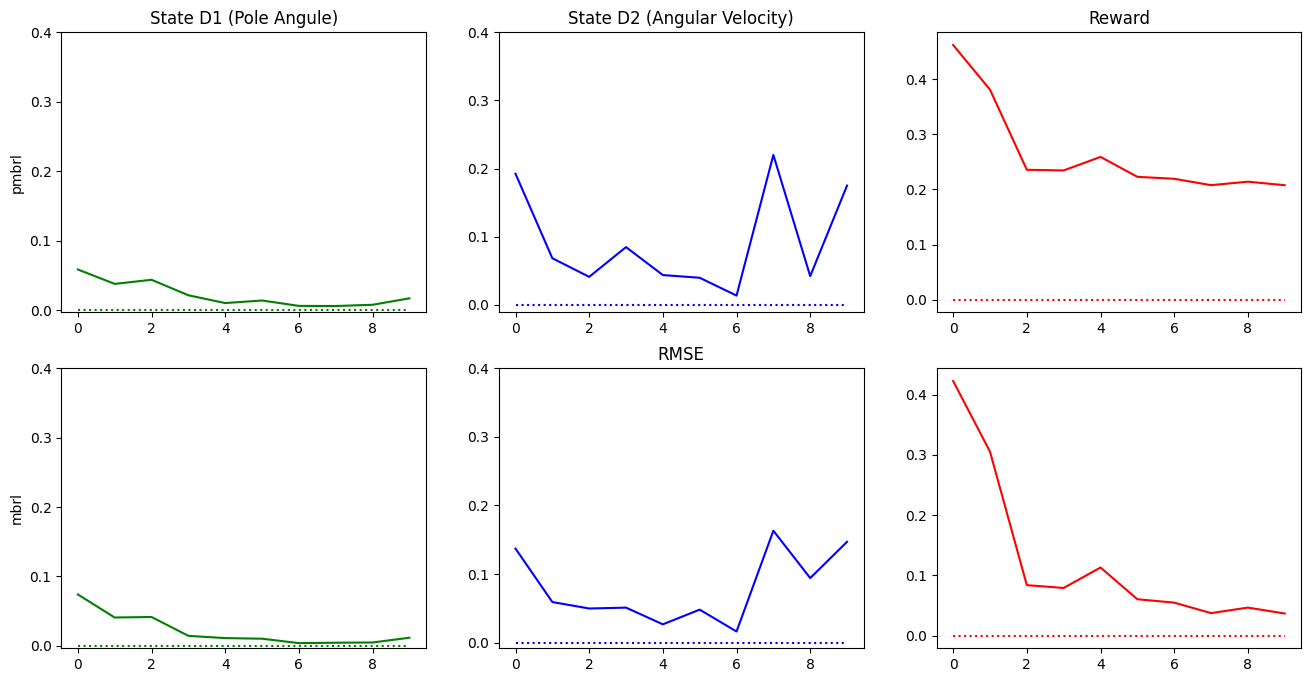

In [68]:
def add_plot(name, data, axis):
    reff = np.zeros(data.shape[0])
    axis[0].set_ylabel(name)
    axis[0].set_ylabel(name)

    axis[0].plot(data['s_0'], color = 'g')
    axis[0].plot(reff, linestyle = 'dotted', color = 'g')
    axis[0].set_yticks(np.arange(5)/10)

    axis[1].plot(data['s_1'], color = 'b')
    axis[1].plot(reff, linestyle = 'dotted', color = 'b')
    axis[1].set_yticks(np.arange(5)/10)

    axis[2].plot(data['r'], color = 'r')
    axis[2].plot(reff, linestyle = 'dotted', color = 'r')
    axis[2].set_yticks(np.arange(5)/10)

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')
axs[0][2].set_title('Reward')
axs[1][1].set_title('RMSE')

add_plot('pmbrl', pmbrl_plot, axs[0])
add_plot('mbrl', mbrl_plot, axs[1])

plt.show()